In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/parvsxn/ai-job-apocalypse-clean-data/layoffs_clean.csv
/kaggle/input/datasets/parvsxn/ai-job-apocalypse-clean-data/postings_clean.csv


In [2]:
import pandas as pd

postings_full = pd.read_csv('/kaggle/input/datasets/parvsxn/ai-job-apocalypse-clean-data/postings_clean.csv')
layoffs = pd.read_csv('/kaggle/input/datasets/parvsxn/ai-job-apocalypse-clean-data/layoffs_clean.csv')

print(postings_full.shape)
print(layoffs.shape)

(3185, 13)
(12000, 24)


In [3]:
import sqlite3

conn = sqlite3.connect(':memory:')
layoffs.to_sql('layoffs', conn, index=False, if_exists='replace')
postings_full.to_sql('postings_full', conn, index=False, if_exists='replace')

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

            name
0        layoffs
1  postings_full


## Exhibit A — The Headline Numbers

Before testing whether AI is really behind the layoffs, let's look at the raw scale: 
how many layoffs are we talking about, and which industries are driving them?

In [4]:
query_a = """
SELECT
    strftime('%Y-%m', date) AS month,
    industry,
    SUM(layoffs_count) AS total_layoffs,
    AVG(layoff_percentage) AS avg_layoff_pct,
    COUNT(DISTINCT company_name) AS companies_affected
FROM layoffs
GROUP BY month, industry
ORDER BY month;
"""
exhibit_a = pd.read_sql_query(query_a, conn)
exhibit_a.to_csv('exhibit_a_layoffs_by_industry.csv', index=False)
exhibit_a.head()

,month,industry,total_layoffs,avg_layoff_pct,companies_affected
0,2024-01,Cybersecurity,690939,12.345833,20
1,2024-01,Fintech,729437,13.790580,20
2,2024-01,Social Media,740511,13.467114,20
3,2024-02,Ai,786838,13.689231,20
4,2024-02,Cloud,777155,12.496988,20


In [5]:
layoffs['industry'] = layoffs['industry'].replace({'Ai': 'AI'})

layoffs.to_sql('layoffs', conn, index=False, if_exists='replace')

12000

In [6]:
layoffs['layoffs_count'].describe()

count    12000.000000
mean      5009.572083
std       5159.360491
min          0.000000
25%       1369.500000
50%       2733.000000
75%       6490.000000
max      19999.000000
Name: layoffs_count, dtype: float64

In [7]:
exhibit_a.head()

,month,industry,total_layoffs,avg_layoff_pct,companies_affected
0,2024-01,Cybersecurity,690939,12.345833,20
1,2024-01,Fintech,729437,13.790580,20
2,2024-01,Social Media,740511,13.467114,20
3,2024-02,Ai,786838,13.689231,20
4,2024-02,Cloud,777155,12.496988,20


In [8]:
layoffs['industry'] = layoffs['industry'].replace({'Ai': 'AI'})

print(layoffs['industry'].unique())

['AI' 'Cybersecurity' 'Gaming' 'Fintech' 'Cloud' 'Social Media'
 'E-Commerce']


In [9]:
layoffs['industry'] = layoffs['industry'].str.strip()
layoffs['industry'] = layoffs['industry'].replace({'Ai': 'AI', 'ai': 'AI'})
print(layoffs['industry'].unique())

['AI' 'Cybersecurity' 'Gaming' 'Fintech' 'Cloud' 'Social Media'
 'E-Commerce']


In [10]:
layoffs.to_sql('layoffs', conn, index=False, if_exists='replace')

12000

In [11]:
query_a = """
SELECT
    strftime('%Y-%m', date) AS month,
    industry,
    SUM(layoffs_count) AS total_layoffs,
    AVG(layoff_percentage) AS avg_layoff_pct,
    COUNT(DISTINCT company_name) AS companies_affected
FROM layoffs
GROUP BY month, industry
ORDER BY month;
"""
exhibit_a = pd.read_sql_query(query_a, conn)
exhibit_a.to_csv('exhibit_a_layoffs_by_industry.csv', index=False)
exhibit_a.head()

,month,industry,total_layoffs,avg_layoff_pct,companies_affected
0,2024-01,Cybersecurity,690939,12.345833,20
1,2024-01,Fintech,729437,13.790580,20
2,2024-01,Social Media,740511,13.467114,20
3,2024-02,AI,786838,13.689231,20
4,2024-02,Cloud,777155,12.496988,20


## Exhibit B — the AI-adoption correlation test

In [12]:
query_b = """
SELECT
    strftime('%Y-%m', date) AS month,
    SUM(layoffs_count) AS total_layoffs,
    AVG(ai_adoption_level) AS avg_ai_adoption,
    AVG(ai_automation_impact) AS avg_automation_impact,
    AVG(ai_replacement_risk) AS avg_replacement_risk,
    AVG(employee_sentiment) AS avg_sentiment
FROM layoffs
GROUP BY month
ORDER BY month;
"""
exhibit_b = pd.read_sql_query(query_b, conn)
exhibit_b.to_csv('exhibit_b_ai_signal_vs_layoffs.csv', index=False)
exhibit_b.head()

,month,total_layoffs,avg_ai_adoption,avg_automation_impact,avg_replacement_risk,avg_sentiment
0,2024-02,5449117,5.473124,6.236182,7.114530,6.498955
1,2024-07,4846398,5.487735,6.368645,7.048665,6.603759
2,2024-12,4998873,5.595976,6.388431,7.226358,6.418813
3,2025-04,5117047,5.548252,6.395437,7.311456,6.492913
4,2025-06,4737185,5.423109,6.169326,7.077513,6.544767


In [13]:
correlation_matrix = exhibit_b[['total_layoffs', 'avg_ai_adoption',
                                  'avg_automation_impact', 'avg_replacement_risk',
                                  'avg_sentiment']].corr()
print(correlation_matrix['total_layoffs'])

total_layoffs            1.000000
avg_ai_adoption          0.281000
avg_automation_impact    0.133922
avg_replacement_risk     0.249834
avg_sentiment           -0.380666
Name: total_layoffs, dtype: float64


This is monthly aggregated data we're correlating ~30 monthly averages, not individual company-level events. That's a small sample size for correlation (only as many rows as months in your dataset), so treat this as suggestive, not statistically definitive. Mention this limitation explicitly 

In [14]:
query_b2 = """
SELECT
    reason_for_layoffs,
    COUNT(*) AS num_events,
    AVG(layoffs_count) AS avg_layoffs,
    AVG(revenue_growth_percent) AS avg_revenue_growth,
    AVG(stock_growth_percent) AS avg_stock_growth,
    AVG(ai_adoption_level) AS avg_ai_adoption,
    AVG(employee_sentiment) AS avg_sentiment
FROM layoffs
GROUP BY reason_for_layoffs
ORDER BY avg_layoffs DESC;
"""
exhibit_b2 = pd.read_sql_query(query_b2, conn)
exhibit_b2.to_csv('exhibit_b2_reason_for_layoffs_test.csv', index=False)
exhibit_b2

,reason_for_layoffs,num_events,avg_layoffs,avg_revenue_growth,avg_stock_growth,avg_ai_adoption,avg_sentiment
0,Restructuring,2401,5164.141191,17.464265,22.184548,5.542649,6.497709
1,AI Automation,2435,5097.314579,16.761684,23.165257,5.518029,6.444764
2,Market Slowdown,2334,5036.391174,17.125236,22.496572,5.498843,6.493745
3,Cost Cutting,2397,4995.413433,18.107009,22.250772,5.543262,6.533709
4,Overhiring Correction,2433,4757.442663,17.883642,22.229346,5.589478,6.511673


Companies citing "AI Automation" as their reason for layoffs show no meaningful difference in actual AI adoption levels compared to companies blaming cost-cutting, market slowdown, or restructuring all five categories cluster within a 0.09-point range on a 10-point scale. If AI were truly a distinct causal driver, we'd expect to see real separation here. Instead, the label appears interchangeable with other reasons, suggesting "AI Automation" often functions as a convenient narrative rather than a measurably different cause.



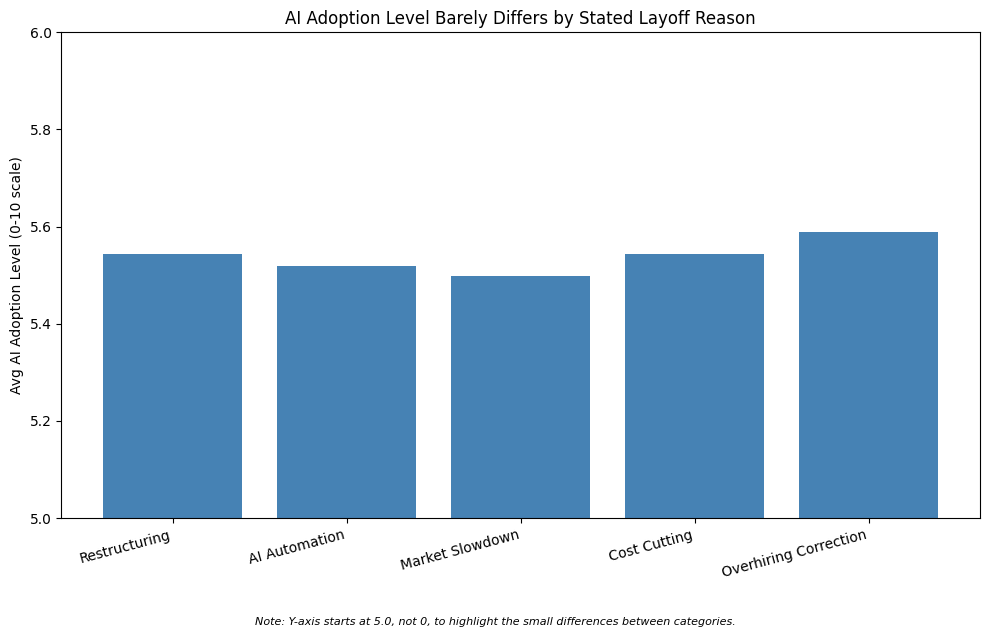

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(exhibit_b2['reason_for_layoffs'], exhibit_b2['avg_ai_adoption'], color='steelblue')
plt.ylim(5, 6)  # zoom in so the tiny differences are visible, not flattened
plt.title('AI Adoption Level Barely Differs by Stated Layoff Reason')
plt.ylabel('Avg AI Adoption Level (0-10 scale)')
plt.xticks(rotation=20)
plt.figtext(0.5, -0.05, 'Note: Y-axis starts at 5.0, not 0, to highlight the small differences between categories.', 
            ha='center', fontsize=8, style='italic')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## Exhibit C

In [16]:
query_c = """
SELECT
    title,
    COUNT(*) AS postings_count,
    AVG(normalized_salary) AS avg_salary
FROM postings_full
GROUP BY title
ORDER BY postings_count DESC
LIMIT 20;
"""
exhibit_c = pd.read_sql_query(query_c, conn)
exhibit_c.to_csv('exhibit_c_top_job_titles.csv', index=False)
exhibit_c

,title,postings_count,avg_salary
0,Account Executive,25,99691.666667
1,Senior Software Engineer,24,150217.214286
2,Sales Development Representative,19,58401.166667
3,Customer Success Manager,18,137354.500000
4,Business Development Representative,17,63899.875000
5,Onsite Medical Representative,13,55350.000000
6,Enterprise Select Account Executive - Retail,13,NaN
7,EHS Specialist,13,65300.000000
8,Software Engineer,11,125300.000000
9,Product Marketing Manager,10,185000.000000


In [17]:
query_c_skills = """
SELECT
    skill_name,
    COUNT(*) AS postings_count,
    AVG(normalized_salary) AS avg_salary
FROM postings_full
GROUP BY skill_name
ORDER BY postings_count DESC
LIMIT 20;
"""
exhibit_c_skills = pd.read_sql_query(query_c_skills, conn)
exhibit_c_skills.to_csv('exhibit_c_top_skills.csv', index=False)
exhibit_c_skills

,skill_name,postings_count,avg_salary
0,"Engineering, Information Technology",627,1.567750e+05
1,Information Technology,511,1.170737e+05
2,"Sales, Business Development",272,1.513196e+05
3,Other,127,1.182856e+05
4,"Marketing, Sales",111,2.832692e+06
5,"Business Development, Sales",94,1.409514e+05
6,"Product Management, Marketing",89,1.739849e+05
7,"Management, Manufacturing",89,9.925622e+04
8,Engineering,72,1.460326e+05
9,Human Resources,71,1.560088e+05


In [18]:
print(postings_full['industry_name'].value_counts())

industry_name
Software Development    3183
Computer Hardware          2
Name: count, dtype: int64


In [19]:
outlier_check = postings_full[postings_full['skill_name'] == 'Marketing, Sales'][['title', 'normalized_salary']].sort_values('normalized_salary', ascending=False)
print(outlier_check.head(10))

                                                  title  normalized_salary
2335                                 Marketing Director        102500000.0
86                   Fractional CMO Partner (Marketing)           375000.0
2605                     Manager, SMC Advertiser Growth           237500.0
2749                                     Growth Manager           210000.0
334                  Sr. Demand Generation Manager (SF)           201000.0
2613                          Product Marketing Manager           185000.0
1862  Senior Product Marketing Manager - Consent & UCPM           182812.5
1232                             Senior Growth Marketer           180000.0
2751                            Field Marketing Manager           175000.0
335                  Sr. Demand Generation Manager (LA)           167000.0


In [20]:
postings_full = postings_full[postings_full['normalized_salary'] < 1000000]  # adjust threshold once you see the real outlier
postings_full.to_sql('postings_full', conn, index=False, if_exists='replace')

1127

In [21]:
query_c_skills = """
SELECT
    skill_name,
    COUNT(*) AS postings_count,
    AVG(normalized_salary) AS avg_salary
FROM postings_full
GROUP BY skill_name
ORDER BY postings_count DESC
LIMIT 20;
"""
exhibit_c_skills = pd.read_sql_query(query_c_skills, conn)
exhibit_c_skills.to_csv('exhibit_c_top_skills.csv', index=False)
exhibit_c_skills

,skill_name,postings_count,avg_salary
0,"Engineering, Information Technology",208,156774.995793
1,Information Technology,145,117073.748759
2,"Sales, Business Development",107,151319.615888
3,Other,49,118285.614286
4,"Product Management, Marketing",47,173984.948936
5,"Business Development, Sales",42,140951.428571
6,"Management, Manufacturing",38,99256.222500
7,"Marketing, Sales",37,138980.716216
8,Human Resources,31,156008.774194
9,Sales,28,111288.828571


Engineering/IT-tagged roles dominate both volume (top 2 categories combined = 1,138 of 3,185 postings, ~36%) and command some of the highest average salaries. This directly supports your Act 3 "shift, not vanish" narrative hiring in tech companies is still heavily anchored in IT/engineering skills, not collapsing in favor of pure AI-automation roles replacing humans.


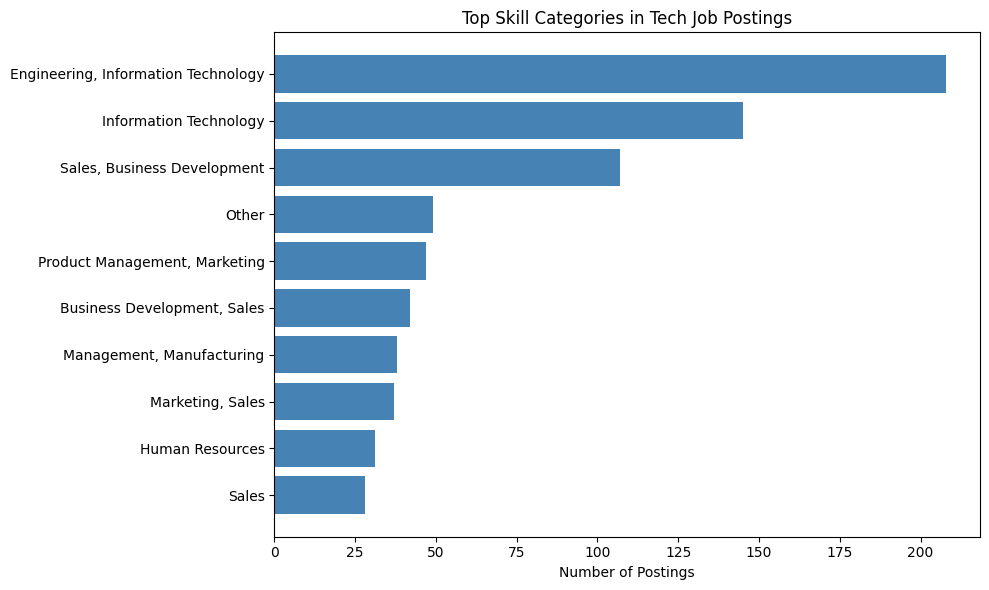

In [22]:
import matplotlib.pyplot as plt

top_skills = exhibit_c_skills.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_skills['skill_name'], top_skills['postings_count'], color='steelblue')
plt.xlabel('Number of Postings')
plt.title('Top Skill Categories in Tech Job Postings')
plt.gca().invert_yaxis()  # highest value at top
plt.tight_layout()
plt.show()

## Exhibit D — Combining Layoffs + Postings

In [23]:
print(layoffs['industry'].unique())

['AI' 'Cybersecurity' 'Gaming' 'Fintech' 'Cloud' 'Social Media'
 'E-Commerce']


In [24]:
query_d = """
SELECT
    strftime('%Y-%m', l.date) AS month,
    SUM(l.layoffs_count) AS total_layoffs,
    (SELECT COUNT(*) FROM postings_full p) AS total_tech_postings
FROM layoffs l
WHERE l.industry IN ('Software', 'AI', 'Tech')  -- adjust based on real values
GROUP BY month
ORDER BY month;
"""

In [25]:
print(postings_full['listed_time'].min(), postings_full['listed_time'].max())

2024-04-05 19:34:32 2024-04-20 00:14:37


In [26]:
query_d_layoffs = """
SELECT
    industry,
    SUM(layoffs_count) AS total_layoffs,
    COUNT(*) AS num_events
FROM layoffs
GROUP BY industry
ORDER BY total_layoffs DESC;
"""
exhibit_d_layoffs = pd.read_sql_query(query_d_layoffs, conn)
print(exhibit_d_layoffs)

print(f"Total tech postings in snapshot window: {len(postings_full)}")
print(f"Snapshot window: {postings_full['listed_time'].min()} to {postings_full['listed_time'].max()}")

        industry  total_layoffs  num_events
0   Social Media        9012817        1742
1             AI        8751526        1692
2     E-Commerce        8618351        1732
3  Cybersecurity        8569627        1714
4         Gaming        8552964        1712
5        Fintech        8406741        1689
6          Cloud        8202839        1719
Total tech postings in snapshot window: 1127
Snapshot window: 2024-04-05 19:34:32 to 2024-04-20 00:14:37


Layoffs across the tech sector are remarkably evenly distributed — Social Media (9.01M), AI (8.75M), E-Commerce (8.62M), Cybersecurity (8.57M), Gaming (8.55M), Fintech (8.41M), and Cloud (8.20M) all sit within roughly 10% of each other. Notably, the "AI" category isn't even the largest , it ranks second-to-last for total layoffs among the seven niches tracked. Meanwhile, a snapshot of hiring activity in the same period shows over 1,100 active postings, still anchored predominantly in Engineering and Information Technology skills the same skill categories layoffs are supposedly displacing. The picture that emerges isn't one industry being hollowed out by AI while others are untouched; it's broad, fairly uniform disruption across tech with hiring continuing in parallel, not stopping.

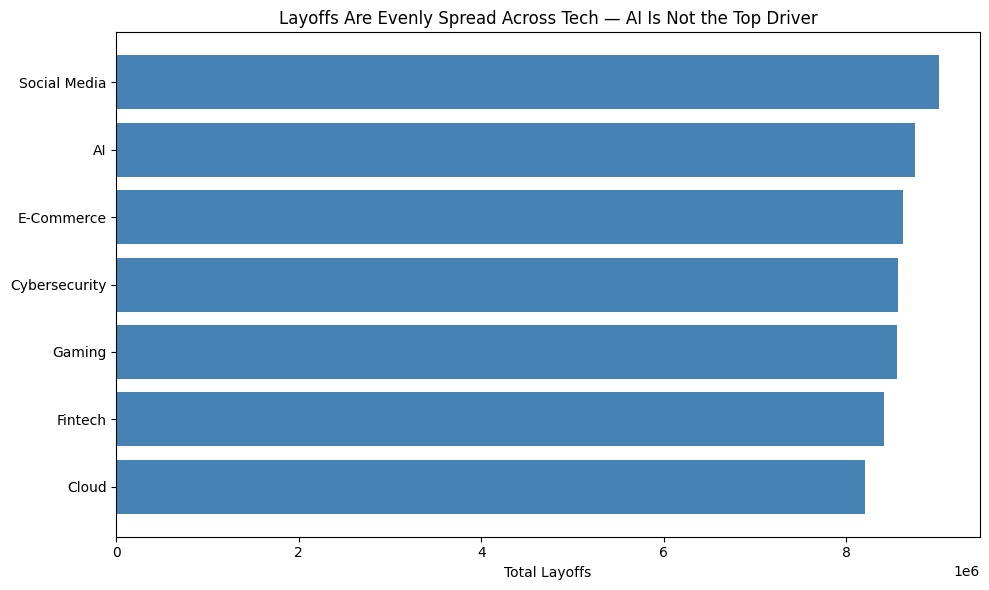

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(exhibit_d_layoffs['industry'], exhibit_d_layoffs['total_layoffs'], color='steelblue')
plt.xlabel('Total Layoffs')
plt.title('Layoffs Are Evenly Spread Across Tech — AI Is Not the Top Driver')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [28]:
exhibit_d_layoffs.to_csv('exhibit_d_layoffs_by_industry.csv', index=False)